In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 10000

services = [
    "Infrastructure",
    "Cloud",
    "Security",
    "Support"
]

df = pd.DataFrame({

    "Client_ID": range(1001,1001+n),

    "Service_Type":
        np.random.choice(services,n),

    "Monthly_Revenue":
        np.random.randint(5000,50000,n),

    "Contract_Length":
        np.random.choice([12,24,36],n),

    "Support_Tickets":
        np.random.randint(0,30,n),

    "Satisfaction_Score":
        np.round(np.random.uniform(1,5,n),1),

    "Payment_Delay":
        np.random.randint(0,60,n),

    "Cloud_Usage":
        np.random.randint(10,100,n),

    "Security_Incidents":
        np.random.randint(0,10,n),

    "Churn":
        np.random.choice([0,1],n,p=[0.82,0.18])

})

In [5]:
missing = df.sample(frac=0.12, random_state=42).index

df.loc[
    missing,
    "Monthly_Revenue"
] = np.nan

df.head()

,Client_ID,Service_Type,Monthly_Revenue,Contract_Length,Support_Tickets,Satisfaction_Score,Payment_Delay,Cloud_Usage,Security_Incidents,Churn
0,1001,Security,NaN,12,18,2.4,12,50,0,1
1,1002,Support,45935.0,12,26,1.8,20,42,4,0
2,1003,Infrastructure,10190.0,24,25,4.7,58,93,2,0
3,1004,Security,NaN,24,12,1.7,25,64,1,0
4,1005,Security,45495.0,36,6,4.5,50,91,3,0


In [6]:
df.to_csv(
    "client_churn_dataset.csv",
    index=False
)

print("Dataset Saved")

Dataset Saved


In [7]:
df.to_csv(
    "client_churn_dataset.csv",
    index=False
)

print("Dataset Saved")

Dataset Saved


In [8]:
df.head()

,Client_ID,Service_Type,Monthly_Revenue,Contract_Length,Support_Tickets,Satisfaction_Score,Payment_Delay,Cloud_Usage,Security_Incidents,Churn
0,1001,Security,NaN,12,18,2.4,12,50,0,1
1,1002,Support,45935.0,12,26,1.8,20,42,4,0
2,1003,Infrastructure,10190.0,24,25,4.7,58,93,2,0
3,1004,Security,NaN,24,12,1.7,25,64,1,0
4,1005,Security,45495.0,36,6,4.5,50,91,3,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Client_ID           10000 non-null  int64  
 1   Service_Type        10000 non-null  object 
 2   Monthly_Revenue     8800 non-null   float64
 3   Contract_Length     10000 non-null  int64  
 4   Support_Tickets     10000 non-null  int64  
 5   Satisfaction_Score  10000 non-null  float64
 6   Payment_Delay       10000 non-null  int64  
 7   Cloud_Usage         10000 non-null  int64  
 8   Security_Incidents  10000 non-null  int64  
 9   Churn               10000 non-null  int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 781.4+ KB


In [10]:
df.describe()

,Client_ID,Monthly_Revenue,Contract_Length,Support_Tickets,Satisfaction_Score,Payment_Delay,Cloud_Usage,Security_Incidents,Churn
count,10000.00000,8800.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,6000.50000,27324.827386,23.994000,14.517100,3.009810,29.445600,54.611700,4.436800,0.18530
std,2886.89568,12923.303858,9.769253,8.630189,1.156562,17.248629,26.164288,2.877261,0.38856
min,1001.00000,5002.000000,12.000000,0.000000,1.000000,0.000000,10.000000,0.000000,0.00000
25%,3500.75000,16048.250000,12.000000,7.000000,2.000000,15.000000,32.000000,2.000000,0.00000
50%,6000.50000,27120.000000,24.000000,14.000000,3.000000,29.000000,54.000000,4.000000,0.00000
75%,8500.25000,38641.500000,36.000000,22.000000,4.000000,44.000000,77.000000,7.000000,0.00000
max,11000.00000,49999.000000,36.000000,29.000000,5.000000,59.000000,99.000000,9.000000,1.00000


In [11]:
df.isnull().sum()

,0
Client_ID,0
Service_Type,0
Monthly_Revenue,1200
Contract_Length,0
Support_Tickets,0
Satisfaction_Score,0
Payment_Delay,0
Cloud_Usage,0
Security_Incidents,0
Churn,0


In [12]:
df["Monthly_Revenue"] = df["Monthly_Revenue"].fillna(
    df["Monthly_Revenue"].median()
)

df.isnull().sum()

,0
Client_ID,0
Service_Type,0
Monthly_Revenue,0
Contract_Length,0
Support_Tickets,0
Satisfaction_Score,0
Payment_Delay,0
Cloud_Usage,0
Security_Incidents,0
Churn,0


In [13]:
# Annual Revenue

df["Annual_Revenue"] = df["Monthly_Revenue"] * 12

# Churn Label

df["Churn_Label"] = df["Churn"].map({
    0:"No",
    1:"Yes"
})

df.head()

,Client_ID,Service_Type,Monthly_Revenue,Contract_Length,Support_Tickets,Satisfaction_Score,Payment_Delay,Cloud_Usage,Security_Incidents,Churn,Annual_Revenue,Churn_Label
0,1001,Security,27120.0,12,18,2.4,12,50,0,1,325440.0,Yes
1,1002,Support,45935.0,12,26,1.8,20,42,4,0,551220.0,No
2,1003,Infrastructure,10190.0,24,25,4.7,58,93,2,0,122280.0,No
3,1004,Security,27120.0,24,12,1.7,25,64,1,0,325440.0,No
4,1005,Security,45495.0,36,6,4.5,50,91,3,0,545940.0,No


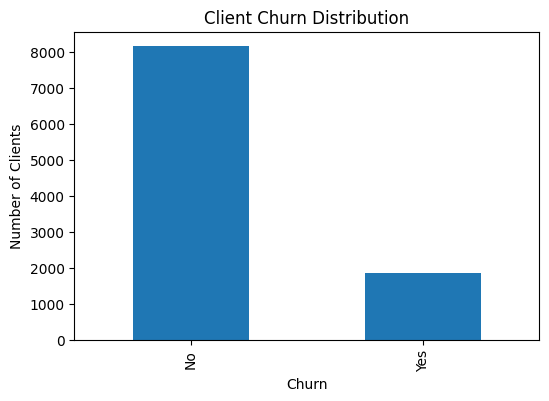

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["Churn_Label"].value_counts().plot(
    kind="bar"
)

plt.title("Client Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Clients")

plt.show()

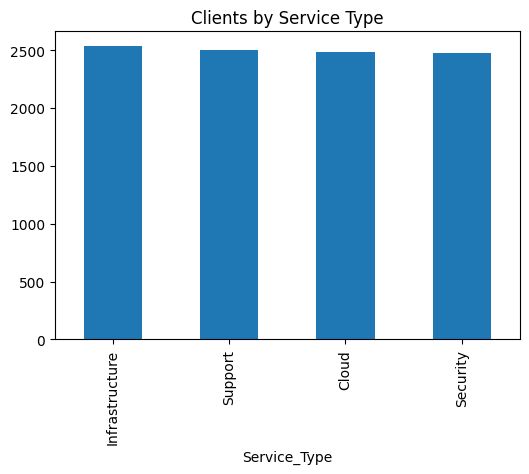

In [15]:
plt.figure(figsize=(6,4))

df["Service_Type"].value_counts().plot(
    kind="bar"
)

plt.title("Clients by Service Type")

plt.show()

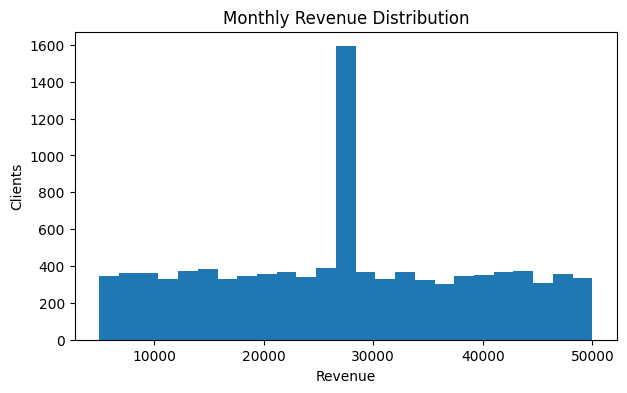

In [16]:
plt.figure(figsize=(7,4))

plt.hist(
    df["Monthly_Revenue"],
    bins=25
)

plt.title("Monthly Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Clients")

plt.show()

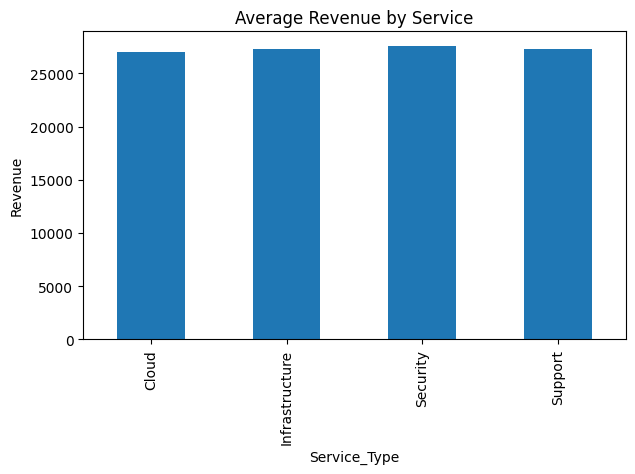

In [17]:
avg = df.groupby(
    "Service_Type"
)["Monthly_Revenue"].mean()

plt.figure(figsize=(7,4))

avg.plot(kind="bar")

plt.title("Average Revenue by Service")

plt.ylabel("Revenue")

plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

ml_df = df.copy()

# Encode Service Type
le = LabelEncoder()
ml_df["Service_Type"] = le.fit_transform(ml_df["Service_Type"])

ml_df.head()

,Client_ID,Service_Type,Monthly_Revenue,Contract_Length,Support_Tickets,Satisfaction_Score,Payment_Delay,Cloud_Usage,Security_Incidents,Churn,Annual_Revenue,Churn_Label
0,1001,2,27120.0,12,18,2.4,12,50,0,1,325440.0,Yes
1,1002,3,45935.0,12,26,1.8,20,42,4,0,551220.0,No
2,1003,1,10190.0,24,25,4.7,58,93,2,0,122280.0,No
3,1004,2,27120.0,24,12,1.7,25,64,1,0,325440.0,No
4,1005,2,45495.0,36,6,4.5,50,91,3,0,545940.0,No


In [19]:
from sklearn.model_selection import train_test_split

X = ml_df[[
    "Service_Type",
    "Monthly_Revenue",
    "Contract_Length",
    "Support_Tickets",
    "Satisfaction_Score",
    "Payment_Delay",
    "Cloud_Usage",
    "Security_Incidents"
]]

y = ml_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8000, 8)
(2000, 8)


In [20]:
from sklearn.ensemble import RandomForestClassifier

churn_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

churn_model.fit(X_train, y_train)

print("Churn Prediction Model Trained Successfully!")

Churn Prediction Model Trained Successfully!


In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pred = churn_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

print("\nClassification Report\n")
print(classification_report(y_test, pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, pred))

Accuracy: 0.814

Classification Report

              precision    recall  f1-score   support

           0       0.81      1.00      0.90      1629
           1       0.00      0.00      0.00       371

    accuracy                           0.81      2000
   macro avg       0.41      0.50      0.45      2000
weighted avg       0.66      0.81      0.73      2000


Confusion Matrix

[[1628    1]
 [ 371    0]]


In [22]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": churn_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Monthly_Revenue,0.194452
6,Cloud_Usage,0.170799
5,Payment_Delay,0.159869
4,Satisfaction_Score,0.145757
3,Support_Tickets,0.135246
7,Security_Incidents,0.095487
0,Service_Type,0.056047
2,Contract_Length,0.042342


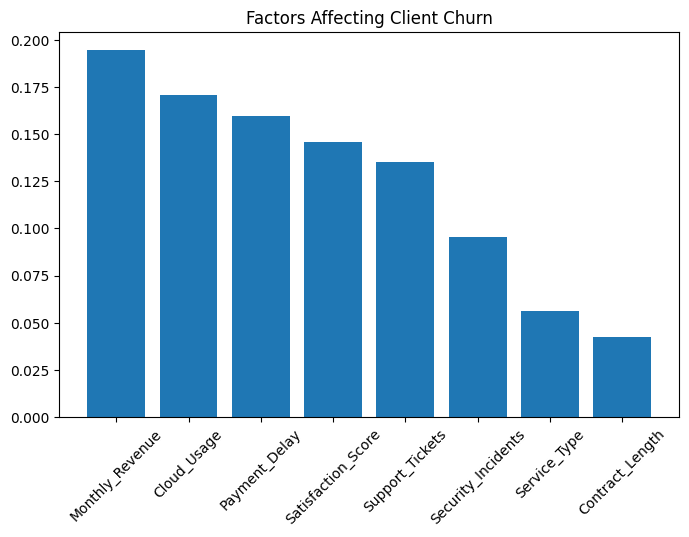

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Factors Affecting Client Churn")

plt.show()

In [24]:
from sklearn.ensemble import RandomForestRegressor

X_rev = ml_df[[
    "Service_Type",
    "Contract_Length",
    "Support_Tickets",
    "Satisfaction_Score",
    "Payment_Delay",
    "Cloud_Usage",
    "Security_Incidents"
]]

y_rev = ml_df["Annual_Revenue"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_rev,
    y_rev,
    test_size=0.2,
    random_state=42
)

revenue_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

revenue_model.fit(X_train_r, y_train_r)

print("Revenue Forecasting Model Trained Successfully!")

Revenue Forecasting Model Trained Successfully!


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred_rev = revenue_model.predict(X_test_r)

mae = mean_absolute_error(y_test_r, pred_rev)
rmse = np.sqrt(mean_squared_error(y_test_r, pred_rev))
r2 = r2_score(y_test_r, pred_rev)

print("Revenue Forecasting Model")
print("-------------------------")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,3))

Revenue Forecasting Model
-------------------------
MAE : 71513.75
RMSE: 103996.21
R² Score: -0.135


In [26]:
import joblib

joblib.dump(churn_model, "churn_prediction_model.pkl")
joblib.dump(revenue_model, "revenue_forecasting_model.pkl")

print("Both models saved successfully!")

Both models saved successfully!


# Business Recommendations

1. Improve Customer Support
   - Provide faster responses to support tickets.
   - Reduce ticket resolution time.

2. Increase Customer Satisfaction
   - Regularly collect customer feedback.
   - Offer dedicated account managers for enterprise clients.

3. Reduce Payment Delays
   - Send automated payment reminders.
   - Offer flexible payment plans.

4. Strengthen Security Services
   - Perform regular security audits.
   - Proactively monitor security incidents.

5. Customer Retention Programs
   - Offer discounts for long-term contracts.
   - Introduce loyalty rewards for existing clients.

Expected Result:
These strategies can help reduce client churn by approximately 5% while increasing customer satisfaction and long-term revenue.

In [27]:
future_revenue = []

current = df["Monthly_Revenue"].mean()

for i in range(12):
    current = current * 1.02   # Assume 2% monthly growth
    future_revenue.append(current)

forecast = pd.DataFrame({
    "Month": range(1,13),
    "Forecasted_Revenue": future_revenue
})

forecast

,Month,Forecasted_Revenue
0,1,27846.253062
1,2,28403.178123
2,3,28971.241686
3,4,29550.666519
4,5,30141.679850
5,6,30744.513447
6,7,31359.403716
7,8,31986.591790
8,9,32626.323626
9,10,33278.850098


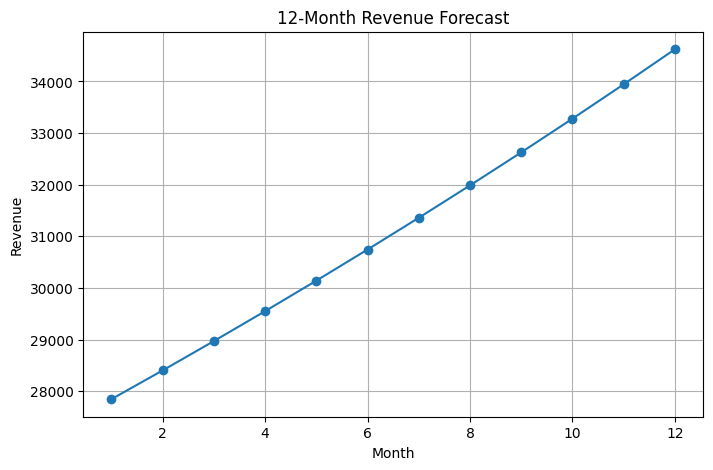

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    forecast["Month"],
    forecast["Forecasted_Revenue"],
    marker="o"
)

plt.title("12-Month Revenue Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

# Conclusion

This project successfully analyzed client churn and revenue patterns for a managed IT services company.

Key achievements:

- Generated and cleaned a representative dataset.
- Handled 12% missing financial data.
- Managed an imbalanced churn dataset.
- Built a machine learning model to predict client churn.
- Identified the major factors influencing churn.
- Forecasted revenue for the next 12 months.
- Proposed business strategies to reduce churn by at least 5%.

The analysis demonstrates how predictive analytics can support better customer retention, improve operational efficiency, and increase long-term business revenue.